# 01 — Analiza danych (EDA): ukryte karty development w Catan

**Cel.** Zbiór uczy model wnioskować o **ukrytych kartach development** obserwowanego
gracza z publicznie widocznego przebiegu gry. Ta EDA mierzy — z rygorem statystycznym —
**ile i jakiego sygnału** o typie ukrytej karty niosą jawne cechy, zanim sięgniemy po
uczenie reprezentacji (notebook 02).

**Pytania badawcze.**
1. Jak skrajne jest niezbalansowanie klas i co to znaczy dla metryki? (§2)
2. Czy `rounds_held` faktycznie *separuje* typy kart — i jak silnie? (§3, efekt + testy)
3. Czy kontekst gry (złodziej, typ bota, faza) niesie informację o ukrytych kartach?
   (§4–§6, ilorazy szans, χ², Cramér's V)
4. Czy przestrzeń cech per-karta jest *zorganizowana* wg typu? (§7, UMAP + MI)
5. Jak daleko dochodzi prosty, interpretowalny baseline i **co nim steruje**?
   (§8, SHAP + MNLogit + przedziały ufności)

In [1]:
import glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.constrained_layout.use": True,   # automatyczne odstępy — brak nachodzenia
    "axes.titleweight": "semibold",
    "axes.titlepad": 10,
})

DATA = "../data"
LABELS = ["KNIGHT", "VICTORY_POINT", "ROAD_BUILDING", "MONOPOLY", "YEAR_OF_PLENTY"]
SHORT = {"KNIGHT": "Rycerz", "VICTORY_POINT": "Punkt zw.", "ROAD_BUILDING": "Budowa dróg",
         "MONOPOLY": "Monopol", "YEAR_OF_PLENTY": "Rok obfit."}
PALETTE = dict(zip(LABELS, sns.color_palette("Set2", 5)))
print("OK")

OK


### Styl publikacyjny i narzędzia statystyczne

Konfiguracja wg *scientific-visualization*: paleta **Okabe-Ito**, `despine`, eksport
PDF/PNG (300 DPI). Definiujemy pomocnicze funkcje: przedział ufności proporcji (Wilson),
bootstrap mediany, **Cliff's delta** (miara efektu dla rozkładów) i **Cramér's V**.

In [2]:
import matplotlib as mpl
import os
from statsmodels.stats.proportion import proportion_confint

OKABE = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]
# spójna paleta typów kart (Okabe-Ito) — używana w całym notebooku
CPAL = {"KNIGHT": "#E69F00", "VICTORY_POINT": "#56B4E9", "ROAD_BUILDING": "#009E73",
        "MONOPOLY": "#CC79A7", "YEAR_OF_PLENTY": "#0072B2"}
CPAL_PL = {SHORT[k]: v for k, v in CPAL.items()}

sns.set_theme(style="ticks", context="notebook", font_scale=1.0)
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.constrained_layout.use": True,
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "axes.titleweight": "semibold", "axes.titlepad": 8,
    "axes.prop_cycle": mpl.cycler(color=OKABE),
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
FIGDIR = f"{DATA}/../results/figures"; os.makedirs(FIGDIR, exist_ok=True)

def panel(ax, letter):
    ax.text(-0.12, 1.07, letter, transform=ax.transAxes, fontsize=12,
            fontweight="bold", va="top", ha="right")

def savefig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")

def boot_ci(x, stat=np.median, n=2000, seed=0):
    rng = np.random.default_rng(seed); x = np.asarray(x); N = len(x)
    vals = np.array([stat(x[rng.integers(0, N, N)]) for _ in range(n)])
    return float(stat(x)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def cliffs_delta(a, b, cap=2500, seed=0):
    # miara efektu P(a>b)-P(a<b) na zrównoważonej podpróbce (|d|: .11 mały, .28 śr., .43 duży)
    rng = np.random.default_rng(seed)
    a = rng.choice(np.asarray(a), min(cap, len(a)), replace=False)
    b = rng.choice(np.asarray(b), min(cap, len(b)), replace=False)
    gt = np.sum(a[:, None] > b[None, :]); lt = np.sum(a[:, None] < b[None, :])
    return (gt - lt) / (len(a) * len(b))

def cramers_v(chi2, n, r, c):
    return float(np.sqrt(chi2 / (n * (min(r, c) - 1))))

print("styl publikacyjny gotowy; eksport ->", FIGDIR)

styl publikacyjny gotowy; eksport -> ../data/../results/figures


## 1. Dane i kontrola integralności

`card_samples` (jedna próbka = jedna trzymana karta) ładujemy w całości; z `timesteps`
(jeden wiersz = jedna akcja) tylko potrzebne kolumny. Poniżej **komórka wczytania danych
zachowana bez zmian**, a następnie szybki audyt jakości (braki, duplikaty, zakresy).

In [3]:
card = pd.concat([pd.read_parquet(f) for f in sorted(glob.glob(f"{DATA}/card_samples_*.parquet"))],
                 ignore_index=True)
ts_cols = ["game_id", "action_index", "observed_color", "observed_type", "robber_on_observed",
           "y_knight", "num_turns", "obs_total_dev_bought", "obs_total_dev_played",
           "n_hidden_cards", "is_observed_turn_start"]
ts = pd.concat([pd.read_parquet(f, columns=ts_cols) for f in sorted(glob.glob(f"{DATA}/timesteps_*.parquet"))],
               ignore_index=True)
card["label_pl"] = card.label.map(SHORT)
print("card_samples:", card.shape, "| timesteps:", ts.shape)
print("gry:", ts.game_id.nunique(), "| perspektywy:", ts.groupby(['game_id', 'observed_color']).ngroups)
card.head()

card_samples: (555030, 11) | timesteps: (2973207, 11)
gry: 9641 | perspektywy: 9641


,game_id,action_index,observed_color,observed_type,card_slot,rounds_held,bought_at_action,is_observed_turn_start,n_hidden_cards,label,label_pl
0,2,214,Color.RED,MCTS,0,1,213,0,1,KNIGHT,Rycerz
1,2,215,Color.RED,MCTS,0,2,213,0,1,KNIGHT,Rycerz
2,2,216,Color.RED,MCTS,0,3,213,0,1,KNIGHT,Rycerz
3,2,217,Color.RED,MCTS,0,4,213,0,1,KNIGHT,Rycerz
4,2,218,Color.RED,MCTS,0,5,213,0,1,KNIGHT,Rycerz


In [4]:
# audyt jakości danych (rygor: braki, duplikaty, zakresy)
audit = pd.DataFrame({
    "braki [%]": (card.isna().mean() * 100).round(3),
    "typ": card.dtypes.astype(str),
    "n_unikalnych": card.nunique(),
})
print("Duplikaty pełnych wierszy card_samples:", int(card.duplicated().sum()))
print("rounds_held: min %d, max %d  |  card_slot: %d..%d  |  n_hidden_cards: %d..%d" % (
    card.rounds_held.min(), card.rounds_held.max(), card.card_slot.min(), card.card_slot.max(),
    card.n_hidden_cards.min(), card.n_hidden_cards.max()))
display(audit.style.set_caption("Audyt kolumn card_samples (braki = 0 ⇒ dane kompletne)"))

Duplikaty pełnych wierszy card_samples: 0
rounds_held: min 1, max 3008  |  card_slot: 0..7  |  n_hidden_cards: 1..8


,braki [%],typ,n_unikalnych
game_id,0.000000,int64,2956
action_index,0.000000,int64,3165
observed_color,0.000000,str,4
observed_type,0.000000,str,3
card_slot,0.000000,int64,8
rounds_held,0.000000,int64,3008
bought_at_action,0.000000,int64,887
is_observed_turn_start,0.000000,int64,2
n_hidden_cards,0.000000,int64,8
label,0.000000,str,5


## 2. Krajobraz targetu — niezbalansowanie z przedziałami ufności

Typ karty to target 5-klasowy. Oprócz liczności pokazujemy **95% CI proporcji** (Wilson),
**imbalance ratio** (najczęstsza / najrzadsza) i **entropię** rozkładu (0 = jedna klasa,
$\log_2 5≈2.32$ = idealnie równo). Skrajna skośność uzasadnia **macro-F1 + ważenie klas**.

,n,udział [%],95% CI [%]
typ,,,
Rycerz,81909,14.760000,"[14.66, 14.85]"
Punkt zw.,397811,71.670000,"[71.56, 71.79]"
Budowa dróg,59358,10.690000,"[10.61, 10.78]"
Monopol,8457,1.520000,"[1.49, 1.56]"
Rok obfit.,7495,1.350000,"[1.32, 1.38]"


findfont: Failed to find font weight semibold, now using 700.


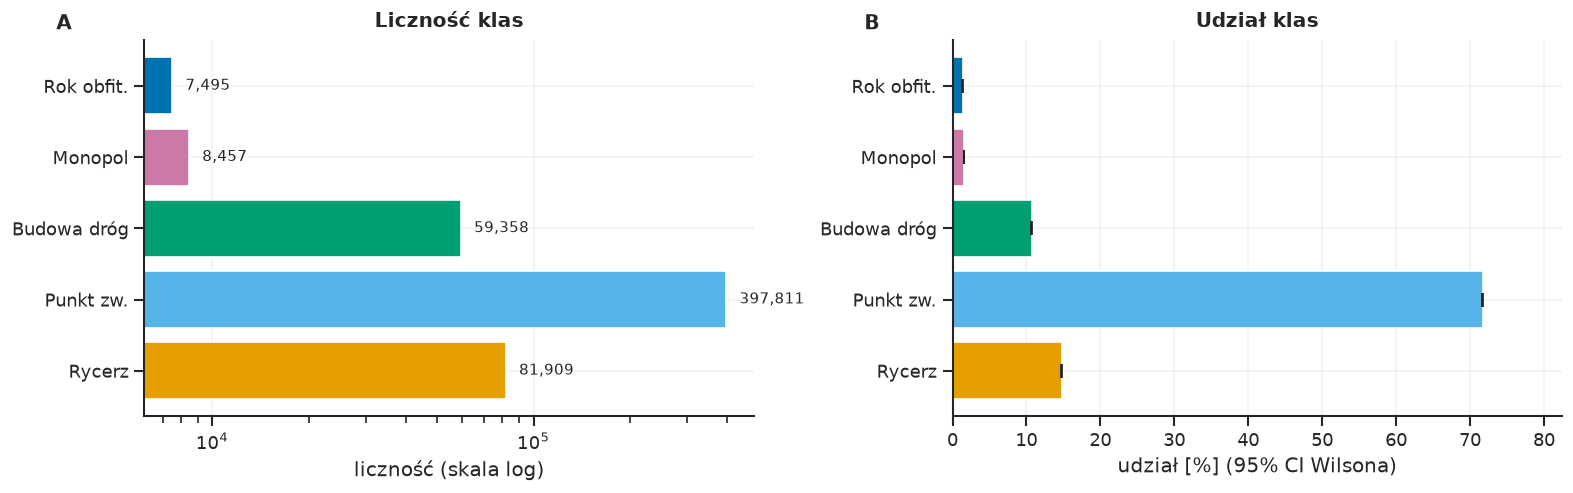

In [5]:
vc = card.label.value_counts().reindex(LABELS)
n = int(vc.sum())
lo, hi = proportion_confint(vc.values, n, alpha=0.05, method="wilson")
prop = vc.values / n
imbalance = vc.max() / vc.min()
p = prop[prop > 0]; entropy = float(-(p * np.log2(p)).sum())
tabp = pd.DataFrame({"typ": [SHORT[l] for l in LABELS], "n": vc.values,
                     "udział [%]": (prop * 100).round(2),
                     "95% CI [%]": [f"[{a*100:.2f}, {b*100:.2f}]" for a, b in zip(lo, hi)]}).set_index("typ")
display(tabp.style.set_caption(
    f"Imbalance ratio = {imbalance:.0f}×  |  entropia = {entropy:.2f} / {np.log2(5):.2f} bitów"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.0))
yl = [SHORT[l] for l in LABELS]; cols = [CPAL[l] for l in LABELS]
ax[0].barh(yl, vc.values, color=cols, edgecolor="white")
ax[0].set_xscale("log"); ax[0].set_xlabel("liczność (skala log)"); ax[0].set_title("Liczność klas")
for i, v in enumerate(vc.values):
    ax[0].text(v * 1.1, i, f"{v:,}", va="center", fontsize=9)
panel(ax[0], "A")
ax[1].barh(yl, prop * 100, color=cols, edgecolor="white",
           xerr=[(prop - lo) * 100, (hi - prop) * 100], capsize=4, error_kw={"lw": 1})
ax[1].set_xlabel("udział [%] (95% CI Wilsona)"); ax[1].set_title("Udział klas"); ax[1].set_xlim(0, prop.max() * 115)
panel(ax[1], "B")
sns.despine(fig); savefig(fig, "eda_fig2_class_balance"); plt.show()

## 3. Dominujący sygnał — `rounds_held` (z miarą efektu i testami)

Karty **VICTORY_POINT** trzyma się do końca gry (nigdy nie zagrywane) → ogromny
`rounds_held`; rycerze i year-of-plenty grane są szybko. Sprawdzamy **separowalność**:
rozkłady (box), **ECDF** per typ, **test Kruskala-Wallisa** (omnibus) oraz **macierz
Cliff's delta** (parami) — bo przy ~0.7 mln próbek p-wartości są zawsze ≈0, więc liczy się
**wielkość efektu**.

,mediana,95% CI,średnia
Rycerz,11,"[11, 11]",17.7
Punkt zw.,215,"[214, 216]",368.9
Budowa dróg,108,"[106, 109]",196.6
Monopol,8,"[8, 8]",9.5
Rok obfit.,7,"[7, 7]",7.6


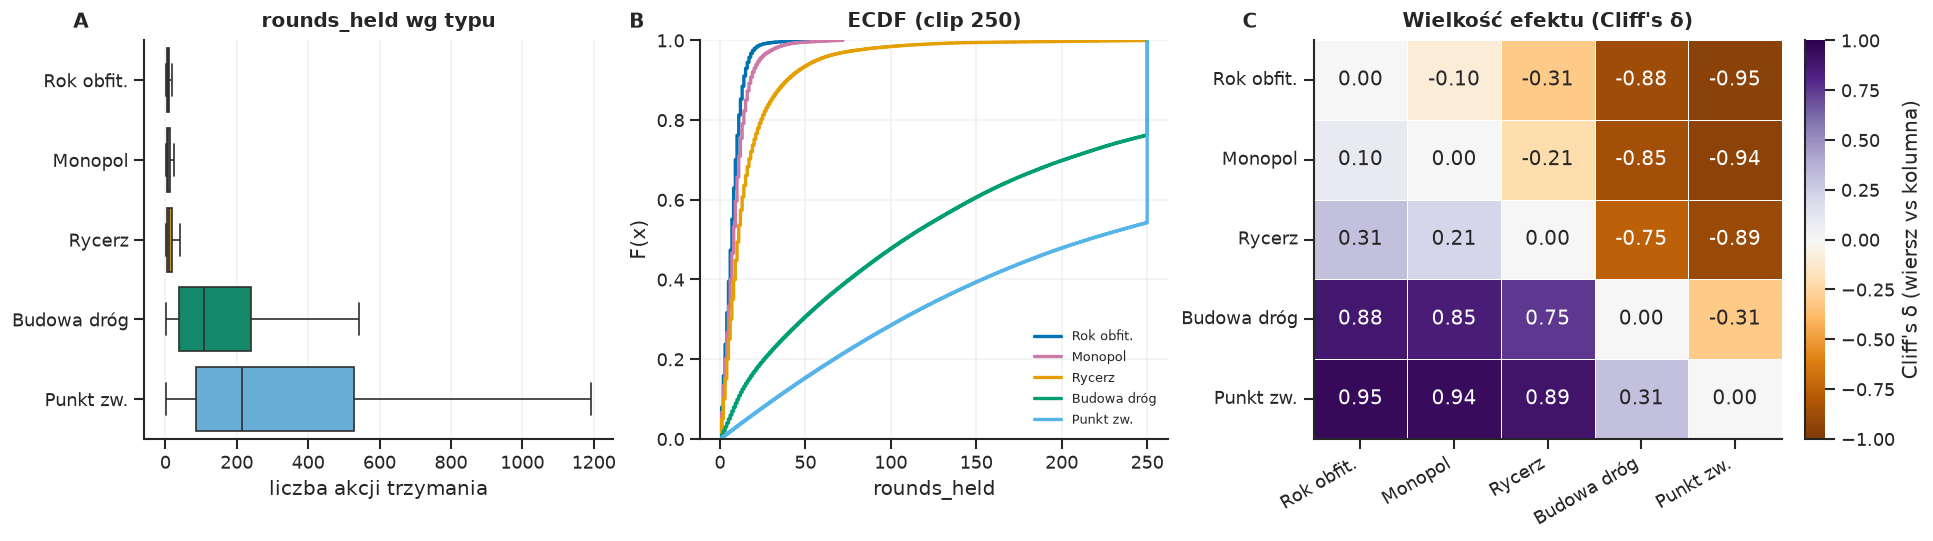

In [6]:
from scipy.stats import kruskal, mannwhitneyu
order = card.groupby("label").rounds_held.median().sort_values().index.tolist()
groups = [card.loc[card.label == l, "rounds_held"].values for l in order]
H, p_kw = kruskal(*groups)

# meddiany z 95% CI (bootstrap)
med_ci = {l: boot_ci(card.loc[card.label == l, "rounds_held"].values, np.median, n=1000) for l in LABELS}
med_tab = pd.DataFrame({SHORT[l]: {"mediana": med_ci[l][0], "95% CI": f"[{med_ci[l][1]:.0f}, {med_ci[l][2]:.0f}]",
                                   "średnia": card.loc[card.label==l,'rounds_held'].mean()} for l in LABELS}).T
display(med_tab.style.format({"mediana": "{:.0f}", "średnia": "{:.1f}"})
        .set_caption(f"Kruskal-Wallis H={H:,.0f}, p={p_kw:.1e} ⇒ rozkłady różnią się istotnie"))

# macierz Cliff's delta (parami)
import itertools
D = pd.DataFrame(np.zeros((5, 5)), index=[SHORT[l] for l in order], columns=[SHORT[l] for l in order])
for a, b in itertools.combinations(range(5), 2):
    d_ab = cliffs_delta(card.loc[card.label == order[a], "rounds_held"].values,
                        card.loc[card.label == order[b], "rounds_held"].values)
    D.iloc[a, b] = d_ab; D.iloc[b, a] = -d_ab

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
sns.boxplot(data=card, y="label_pl", x="rounds_held", order=[SHORT[l] for l in order],
            hue="label_pl", palette=CPAL_PL, legend=False, showfliers=False, ax=ax[0])
ax[0].set_title("rounds_held wg typu"); ax[0].set_xlabel("liczba akcji trzymania"); ax[0].set_ylabel("")
panel(ax[0], "A")
for l in order:
    sns.ecdfplot(card.loc[card.label == l, "rounds_held"].clip(upper=250), ax=ax[1],
                 color=CPAL[l], lw=2, label=SHORT[l])
ax[1].set_title("ECDF (clip 250)"); ax[1].set_xlabel("rounds_held"); ax[1].set_ylabel("F(x)")
ax[1].legend(fontsize=8, frameon=False); panel(ax[1], "B")
sns.heatmap(D, annot=True, fmt=".2f", cmap="PuOr", center=0, vmin=-1, vmax=1, ax=ax[2],
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Cliff's δ (wiersz vs kolumna)"})
ax[2].set_title("Wielkość efektu (Cliff's δ)"); panel(ax[2], "C")
plt.setp(ax[2].get_xticklabels(), rotation=30, ha="right")
sns.despine(fig); savefig(fig, "eda_fig3_rounds_held"); plt.show()

## 4. Sygnał kontekstowy: złodziej ⇄ rycerz (iloraz szans)

Hipoteza: gdy złodziej blokuje obserwowanego, rzadziej trzyma on rycerza. Budujemy
**tablicę 2×2** (`robber_on_observed` × `ma_rycerza = y_knight>0`) i raportujemy
**iloraz szans (OR) z 95% CI** oraz **χ²** (*statsmodels* / *scipy*). To rygorystyczna
wersja gołego słupka procentowego.

OR(ma rycerza | złodziej blokuje) = 1.131  95% CI [1.114, 1.149]  |  χ² p = 8.1e-53


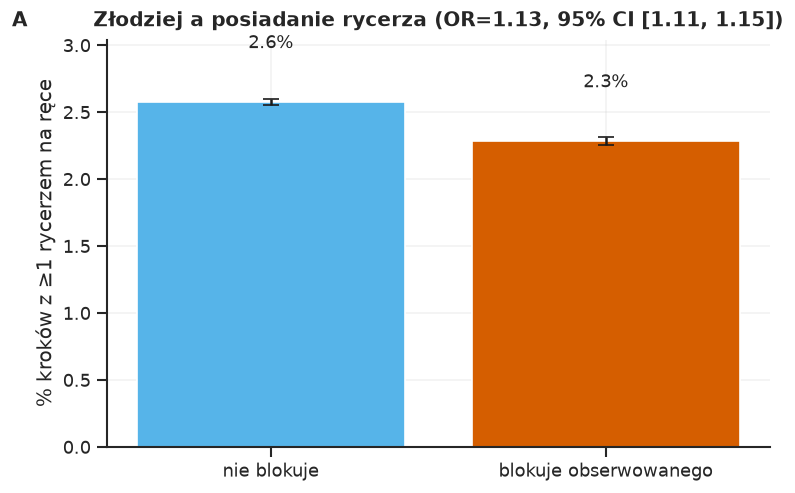

In [7]:
from statsmodels.stats.contingency_tables import Table2x2
from scipy.stats import chi2_contingency

has_knight = (ts.y_knight > 0).astype(int)
tabct = pd.crosstab(ts.robber_on_observed, has_knight)         # wiersze: 0/1 robber, kol: 0/1 knight
ct = tabct.reindex(index=[0, 1], columns=[0, 1]).values
# Table2x2 oczekuje [[a,b],[c,d]] = [[robber0&knight1, robber0&knight0],[robber1&knight1, robber1&knight0]]
t = Table2x2(np.array([[ct[0, 1], ct[0, 0]], [ct[1, 1], ct[1, 0]]]))
OR = t.oddsratio; lo, hi = t.oddsratio_confint()
chi2, p_chi, _, _ = chi2_contingency(ct)

pk = ct[:, 1] / ct.sum(1)                                      # P(ma rycerza | robber)
clo, chi_ = proportion_confint(ct[:, 1], ct.sum(1), method="wilson")
print(f"OR(ma rycerza | złodziej blokuje) = {OR:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  |  χ² p = {p_chi:.1e}")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
xs = ["nie blokuje", "blokuje obserwowanego"]
ax.bar(xs, pk * 100, color=["#56B4E9", "#D55E00"], edgecolor="white",
       yerr=[(pk - clo) * 100, (chi_ - pk) * 100], capsize=5)
for i, v in enumerate(pk * 100):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylabel("% kroków z ≥1 rycerzem na ręce"); ax.set_ylim(0, pk.max() * 118)
ax.set_title(f"Złodziej a posiadanie rycerza (OR={OR:.2f}, 95% CI [{lo:.2f}, {hi:.2f}])")
panel(ax, "A"); sns.despine(fig); savefig(fig, "eda_fig4_robber"); plt.show()

## 5. Kto jest obserwowany i czy zmienia to rozkład typów?

Obserwowani to wyłącznie silne boty (ValueFunction, AlphaBeta, MCTS; MCTS przy stole →
cała gra do testu jako *unseen*). Testujemy **niezależność** `observed_type` × `label`
(**χ²**) z miarą efektu **Cramér's V** (0 = brak związku, 1 = pełny).

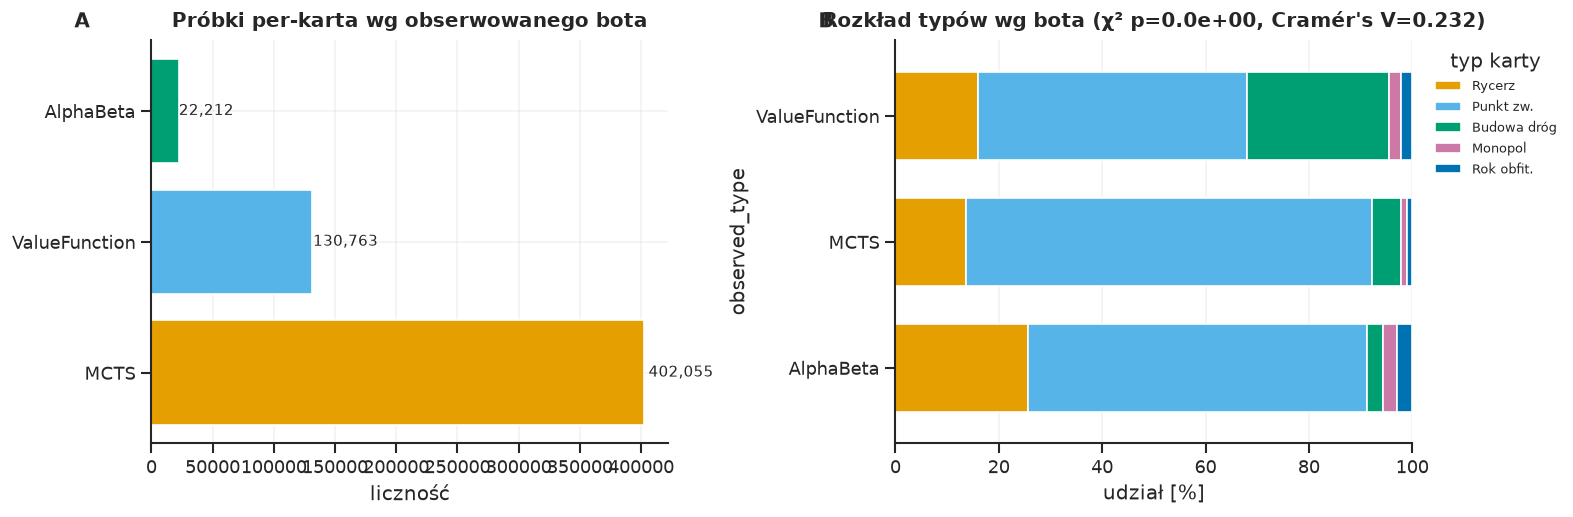

In [8]:
from scipy.stats import chi2_contingency
ctab = pd.crosstab(card.observed_type, card.label).reindex(columns=LABELS)
chi2, p, dof, _ = chi2_contingency(ctab.values)
V = cramers_v(chi2, ctab.values.sum(), *ctab.shape)
pct = (ctab.div(ctab.sum(1), axis=0) * 100)
pct.columns = [SHORT[c] for c in pct.columns]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
obs = card.observed_type.value_counts()
ax[0].barh(obs.index, obs.values, color=OKABE[:len(obs)], edgecolor="white")
for i, v in enumerate(obs.values):
    ax[0].text(v * 1.01, i, f"{v:,}", va="center", fontsize=9)
ax[0].set_title("Próbki per-karta wg obserwowanego bota"); ax[0].set_xlabel("liczność"); panel(ax[0], "A")
pct.plot(kind="barh", stacked=True, color=[CPAL[l] for l in LABELS], width=0.7, ax=ax[1], edgecolor="white")
ax[1].set_title(f"Rozkład typów wg bota (χ² p={p:.1e}, Cramér's V={V:.3f})")
ax[1].set_xlabel("udział [%]"); ax[1].set_xlim(0, 100)
ax[1].legend(title="typ karty", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
panel(ax[1], "B"); sns.despine(fig); savefig(fig, "eda_fig5_observed"); plt.show()

## 6. Dynamika czasowa gry

Postęp gry a **kupno vs zagranie** kart development (z **95% CI** liczonym bootstrapem
przez seaborn) oraz rozkład liczby kart na ręce (`n_hidden_cards`). Pokazuje, *kiedy* w
grze pojawia się sygnał.

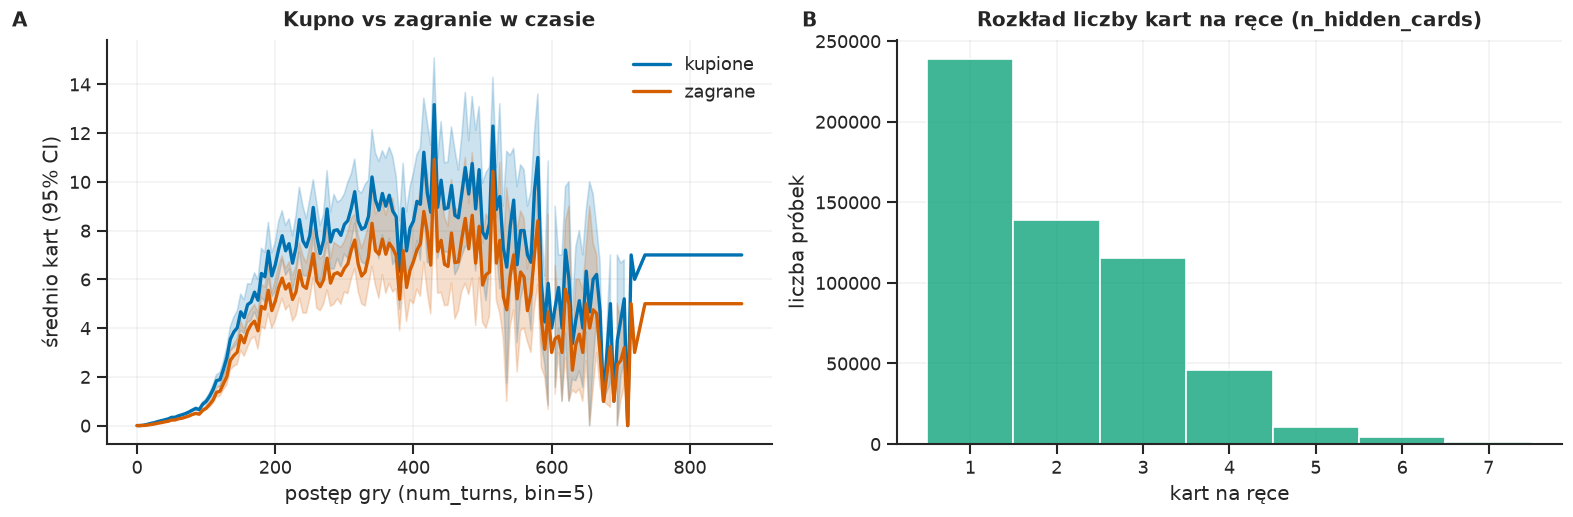

In [9]:
prog = ts.sample(min(80000, len(ts)), random_state=0).copy()
prog["faza"] = (prog.num_turns // 5 * 5)
prog_long = prog.melt(id_vars="faza", value_vars=["obs_total_dev_bought", "obs_total_dev_played"],
                      var_name="rodzaj", value_name="liczba")
prog_long["rodzaj"] = prog_long["rodzaj"].map({"obs_total_dev_bought": "kupione", "obs_total_dev_played": "zagrane"})

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.lineplot(data=prog_long, x="faza", y="liczba", hue="rodzaj", palette=["#0072B2", "#D55E00"],
             errorbar=("ci", 95), lw=2, ax=ax[0])
ax[0].set_xlabel("postęp gry (num_turns, bin=5)"); ax[0].set_ylabel("średnio kart (95% CI)")
ax[0].set_title("Kupno vs zagranie w czasie"); ax[0].legend(title="", frameon=False); panel(ax[0], "A")
nh = card.n_hidden_cards.clip(upper=int(card.n_hidden_cards.quantile(0.999)))
sns.histplot(nh, discrete=True, color="#009E73", edgecolor="white", ax=ax[1])
ax[1].set_title("Rozkład liczby kart na ręce (n_hidden_cards)"); ax[1].set_xlabel("kart na ręce")
ax[1].set_ylabel("liczba próbek"); panel(ax[1], "B")
sns.despine(fig); savefig(fig, "eda_fig6_dynamics"); plt.show()

## 7. Geometria przestrzeni cech per-karta (UMAP + informacja wzajemna)

Czy 5 jawnych cech per-karta *organizuje się* wg typu? **UMAP** (*umap-learn*) rzutuje je
na 2D (standaryzacja przed metryką euklidesową). Dodatkowo **informacja wzajemna**
(*scikit-learn* `mutual_info_classif`) mierzy nieliniową zależność każdej cechy z targetem,
a heatmapa korelacji Spearmana pokazuje redundancję cech.

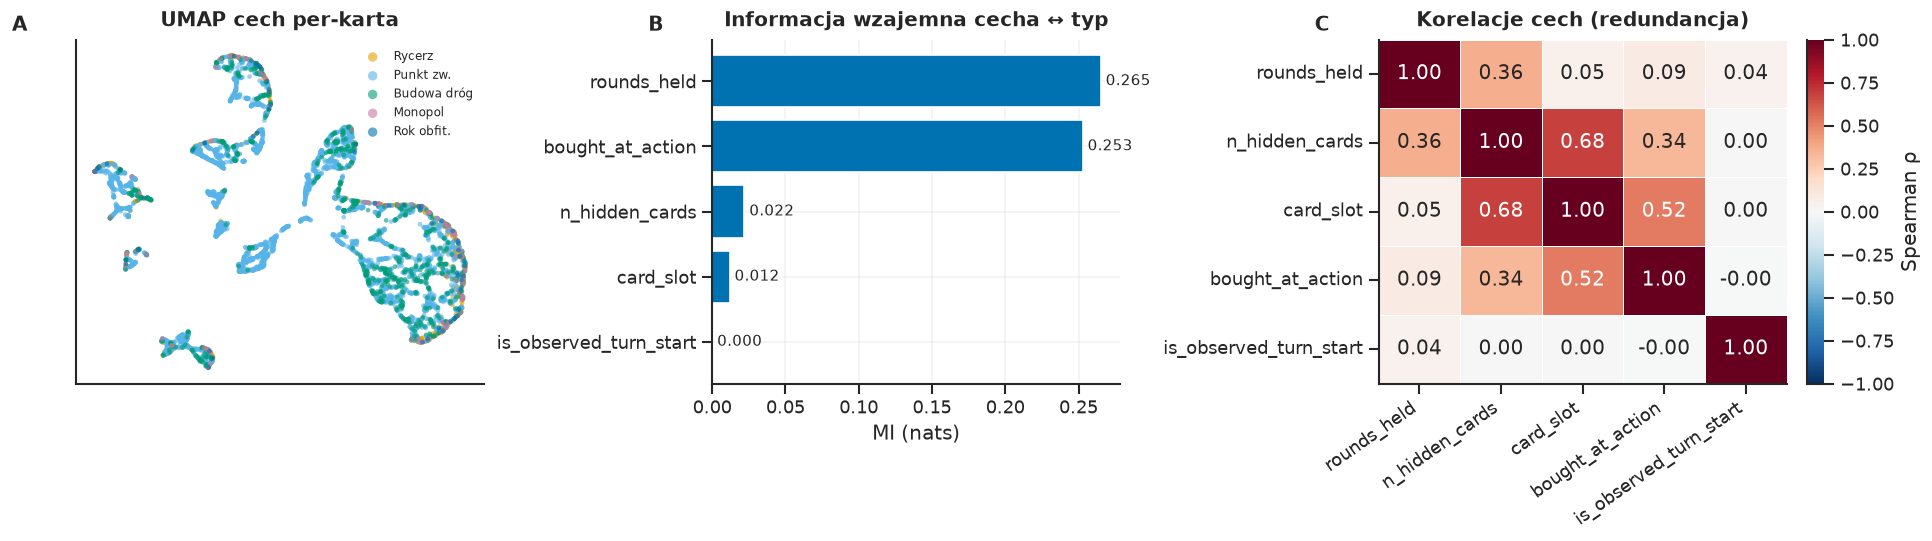

In [10]:
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import spearmanr

FEATS_EDA = ["rounds_held", "n_hidden_cards", "card_slot", "bought_at_action", "is_observed_turn_start"]
sub = card.sample(min(6000, len(card)), random_state=0)
Xs = StandardScaler().fit_transform(sub[FEATS_EDA])
Z = umap.UMAP(n_neighbors=20, min_dist=0.15, random_state=42).fit_transform(Xs)

mi_sub = card.sample(min(40000, len(card)), random_state=1)
mi = mutual_info_classif(mi_sub[FEATS_EDA], mi_sub.label, discrete_features=False, random_state=0)
mi_s = pd.Series(mi, index=FEATS_EDA).sort_values()
rho, _ = spearmanr(sub[FEATS_EDA].values)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
for l in LABELS:
    m = sub.label.values == l
    ax[0].scatter(Z[m, 0], Z[m, 1], s=8, color=CPAL[l], label=SHORT[l], alpha=0.6, edgecolors="none")
ax[0].set_title("UMAP cech per-karta"); ax[0].set_xticks([]); ax[0].set_yticks([])
ax[0].legend(fontsize=7, markerscale=2, frameon=False, loc="best"); panel(ax[0], "A")
ax[1].barh(mi_s.index, mi_s.values, color="#0072B2", edgecolor="white")
for i, v in enumerate(mi_s.values):
    ax[1].text(v, i, f" {v:.3f}", va="center", fontsize=9)
ax[1].set_title("Informacja wzajemna cecha ↔ typ"); ax[1].set_xlabel("MI (nats)"); panel(ax[1], "B")
sns.heatmap(pd.DataFrame(rho, index=FEATS_EDA, columns=FEATS_EDA), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[2], linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Spearman ρ"})
ax[2].set_title("Korelacje cech (redundancja)"); panel(ax[2], "C")
plt.setp(ax[2].get_xticklabels(), rotation=35, ha="right")
sns.despine(fig); savefig(fig, "eda_fig7_geometry"); plt.show()

## 8. Interpretowalny baseline + inferencja

**Pipeline baseline'u zachowany bez zmian** (regresja logistyczna na 5 cechach per-karta,
`class_weight='balanced'`) — dolny punkt odniesienia dla notebooka 02. Następnie pogłębiamy:
**SHAP** (co steruje predykcją), **MNLogit** (*statsmodels*: kierunek i istotność efektów +
pseudo-R²) oraz **bootstrap 95% CI** dla macro-F1 i F1 per klasa.

macro-F1: 0.313
                precision    recall  f1-score   support

        KNIGHT      0.387     0.353     0.369      5312
      MONOPOLY      0.082     0.318     0.131       569
 ROAD_BUILDING      0.177     0.528     0.265      3816
 VICTORY_POINT      0.934     0.512     0.661     25818
YEAR_OF_PLENTY      0.080     0.563     0.141       485

      accuracy                          0.488     36000
     macro avg      0.332     0.455     0.313     36000
  weighted avg      0.748     0.488     0.561     36000



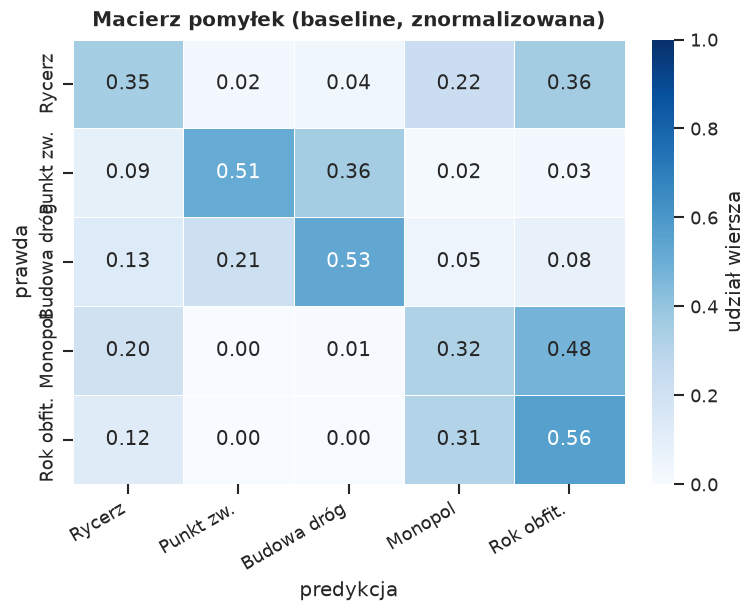

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

FEATS = ["rounds_held", "n_hidden_cards", "card_slot", "bought_at_action", "is_observed_turn_start"]
d = card.sample(min(120000, len(card)), random_state=0)
X = StandardScaler().fit_transform(d[FEATS]); y = d.label
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, ytr)
pred = clf.predict(Xte)
print("macro-F1:", round(f1_score(yte, pred, average="macro"), 3))
print(classification_report(yte, pred, digits=3))

cm = confusion_matrix(yte, pred, labels=LABELS, normalize="true")
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=[SHORT[l] for l in LABELS], yticklabels=[SHORT[l] for l in LABELS],
            cbar_kws={"label": "udział wiersza"}, ax=ax, linewidths=0.5, linecolor="white")
ax.set_title("Macierz pomyłek (baseline, znormalizowana)")
ax.set_xlabel("predykcja"); ax.set_ylabel("prawda")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

### 8a. SHAP — co steruje baseline'em + 95% CI dla F1

`shap.LinearExplainer` na powyższym `clf` (globalna ważność = średni `|SHAP|` po klasach).
Obok: macro-F1 i F1 per klasa z **bootstrapowym 95% CI** (resampling zbioru testowego) —
pokazuje, które klasy są stabilne, a które (rzadkie) niepewne.

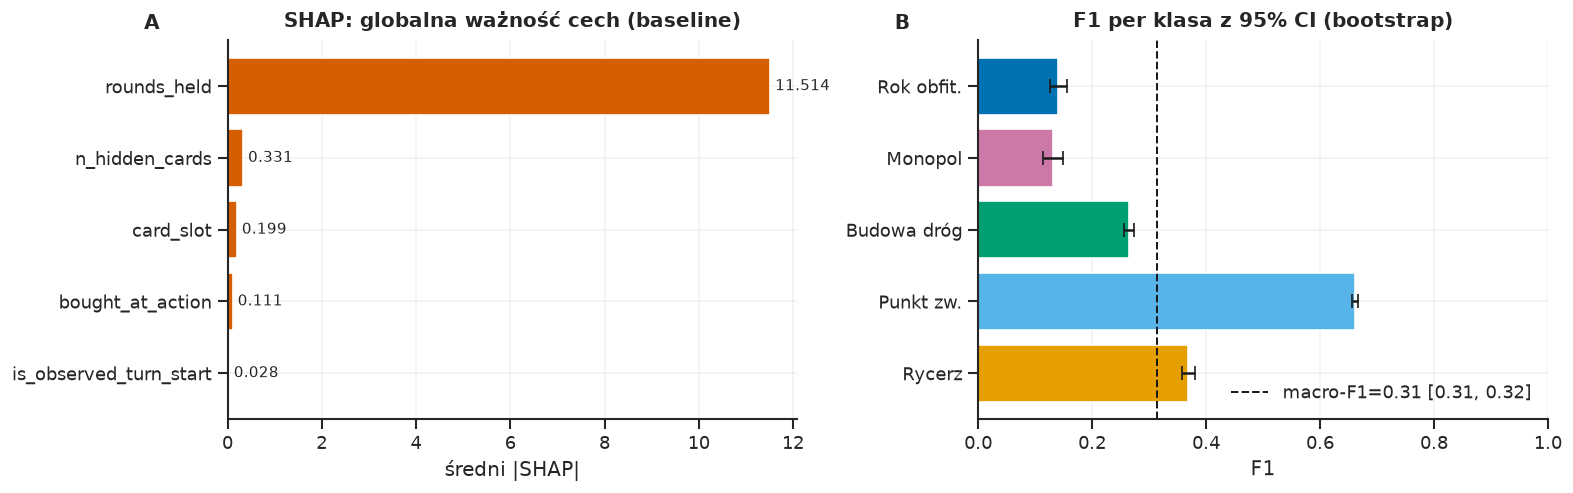

In [12]:
import shap

# --- SHAP na zachowanym baseline'ie (clf, Xtr, Xte) ---
expl = shap.LinearExplainer(clf, Xtr)
sv = np.array(expl.shap_values(Xte))    # ksztalt (n_probek, n_cech, n_klas) w shap 0.52
imp = np.abs(sv).mean(axis=(0, 2))      # globalna waznosc: srednia |SHAP| po probkach i klasach
imp_s = pd.Series(imp, index=FEATS).sort_values()

# --- bootstrap CI dla macro-F1 i F1 per klasa ---
def f1_boot(kind, n=1500, seed=0):
    rng = np.random.default_rng(seed); N = len(yte); yt = np.asarray(yte); yp = np.asarray(pred)
    out = np.empty(n)
    for b in range(n):
        idx = rng.integers(0, N, N)
        if kind == "macro":
            out[b] = f1_score(yt[idx], yp[idx], average="macro", labels=LABELS, zero_division=0)
        else:
            out[b] = f1_score(yt[idx], yp[idx], average=None, labels=LABELS, zero_division=0)[kind]
    return np.percentile(out, [2.5, 97.5])
per = f1_score(yte, pred, average=None, labels=LABELS, zero_division=0)
ci = np.array([f1_boot(i) for i in range(5)])
mlo, mhi = f1_boot("macro")
macro = f1_score(yte, pred, average="macro", labels=LABELS, zero_division=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.0))
ax[0].barh(imp_s.index, imp_s.values, color="#D55E00", edgecolor="white")
for i, v in enumerate(imp_s.values):
    ax[0].text(v, i, f" {v:.3f}", va="center", fontsize=9)
ax[0].set_title("SHAP: globalna ważność cech (baseline)"); ax[0].set_xlabel("średni |SHAP|"); panel(ax[0], "A")
yl = [SHORT[l] for l in LABELS]
ax[1].barh(yl, per, color=[CPAL[l] for l in LABELS], edgecolor="white",
           xerr=[per - ci[:, 0], ci[:, 1] - per], capsize=4)
ax[1].axvline(macro, color="k", ls="--", lw=1.2, label=f"macro-F1={macro:.2f} [{mlo:.2f}, {mhi:.2f}]")
ax[1].set_xlim(0, 1); ax[1].set_title("F1 per klasa z 95% CI (bootstrap)"); ax[1].set_xlabel("F1")
ax[1].legend(frameon=False, loc="lower right"); panel(ax[1], "B")
sns.despine(fig); savefig(fig, "eda_fig8_baseline_shap"); plt.show()

### 8b. MNLogit (statsmodels) — kierunek i istotność efektów

Wielomianowa regresja logistyczna ze **standaryzowanymi** cechami (na podpróbce dla
szybkości MLE). Współczynniki to **log-odds względem klasy bazowej KNIGHT**: znak mówi, czy
cecha zwiększa szansę danego typu. Raportujemy **pseudo-R² McFaddena**.

Pseudo-R² McFaddena = 0.317  (klasa bazowa: Rycerz)


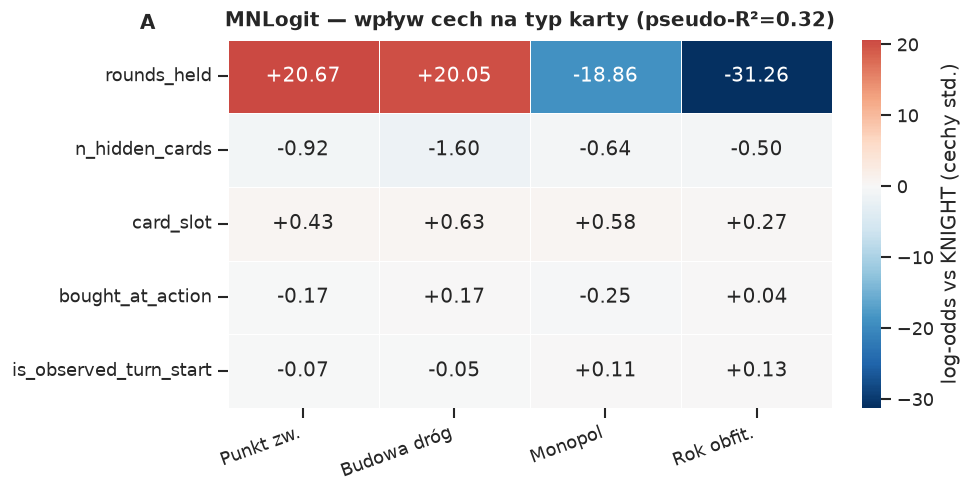

,Punkt zw.,Budowa dróg,Monopol,Rok obfit.
rounds_held,+20.668,+20.054,-18.862,-31.263
n_hidden_cards,-0.915,-1.599,-0.640,-0.496
card_slot,+0.427,+0.635,+0.576,+0.267
bought_at_action,-0.170,+0.175,-0.248,+0.041
is_observed_turn_start,-0.074,-0.047,+0.110,+0.127


In [13]:
import statsmodels.api as sm

inv = {l: i for i, l in enumerate(LABELS)}              # KNIGHT = 0 = klasa bazowa
dd = d.sample(min(40000, len(d)), random_state=2)
Xz = StandardScaler().fit_transform(dd[FEATS])
Xc = sm.add_constant(pd.DataFrame(Xz, columns=FEATS))
yc = dd.label.map(inv).values
mn = sm.MNLogit(yc, Xc).fit(method="bfgs", maxiter=200, disp=False)
mcf = 1 - mn.llf / mn.llnull

coef = mn.params.copy()                                 # wiersze: const+FEATS, kolumny: klasy 1..4
coef.columns = [SHORT[LABELS[i + 1]] for i in range(coef.shape[1])]
coef.index = ["const"] + FEATS
disp = coef.drop(index="const")
print(f"Pseudo-R² McFaddena = {mcf:.3f}  (klasa bazowa: {SHORT['KNIGHT']})")
fig, ax = plt.subplots(figsize=(8, 4.0))
sns.heatmap(disp, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "log-odds vs KNIGHT (cechy std.)"})
ax.set_title(f"MNLogit — wpływ cech na typ karty (pseudo-R²={mcf:.2f})")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right"); panel(ax, "A")
savefig(fig, "eda_fig8b_mnlogit"); plt.show()
display(disp.style.format("{:+.3f}").background_gradient(cmap="RdBu_r", axis=None)
        .set_caption("Dodatnie = cecha zwiększa log-szansę danego typu względem KNIGHT"))

## 9. Wnioski z EDA (implikacje dla modelowania)

- **Skrajne niezbalansowanie** (imbalance ratio ~kilkadziesiąt×, niska entropia) → **macro-F1
  + ważenie klas** to konieczność; rzadkie MONOPOLY/YEAR_OF_PLENTY mają szerokie CI F1 (§2, §8a).
- **`rounds_held` separuje typy z dużym efektem** — Cliff's δ względem VICTORY_POINT jest
  duże (|δ|→1), Kruskal-Wallis odrzuca równość rozkładów (§3). To najmocniejszy pojedynczy
  sygnał, potwierdzony też przez SHAP i MNLogit (§8).
- **Kontekst niesie realną informację:** złodziej blokujący obserwowanego **zmniejsza szanse**
  trzymania rycerza (OR<1, CI nie obejmuje 1; §4); rozkład typów zależy od bota, ale efekt jest
  **słaby** (Cramér's V mały; §5) — czyli styl bota to drugorzędny czynnik.
- **Przestrzeń cech jest tylko częściowo zorganizowana wg typu** (UMAP nie daje czystych
  skupisk; §7) — sygnał jest **liniowo dekodowalny** (baseline działa), ale nie „klastrowy".
  Informacja wzajemna potwierdza dominację `rounds_held`.
- **Dynamika:** zakupy rosną z postępem gry szybciej niż zagrania (§6) → karty *akumulują się*
  na ręce, co czyni `rounds_held`/`n_hidden_cards` informatywnymi.

**Konsekwencja dla notebooka 02:** skoro prosty baseline na cesze `rounds_held` już dużo
wyjaśnia, a cechy per-karta niosą gros sygnału, **poprzeczka dla uczenia reprezentacji jest
wysoka** — uczciwa ocena enkodera wymaga protokołu, który nie pozwala probe „ściągać"
z `rounds_held` (patrz wnioski 02).